# 已知非线性动力学下的 TM/PEID 与 SHAP 对照

这个 notebook 只保留实验报告层：用已知动力学检验 transport-map PEID 是否能读出人为注入的协同结构，并补充 TreeSHAP 的主效应/交互值作为模型解释基线。示意图已删除，长函数、缓存写入和绘图逻辑放在 `scripts/tm_nonlinear.py`。

In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MPLCONFIGDIR", str((Path.cwd().resolve() / "tmp" / "matplotlib").resolve()))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = None
for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate / "utils.py").exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    raise RuntimeError("Could not locate project root from current working directory.")

from scripts.tm_nonlinear import (
    DEFAULT_ALPHA_VALUES,
    DEFAULT_BETA_VALUES,
    DEFAULT_L_SWEEP_ALPHA_VALUES,
    DEFAULT_L_VALUES,
    DEFAULT_NOISE_STD_VALUES,
    DEFAULT_NOISE_SWEEP_ALPHA_VALUES,
    ShapConfig,
    TmNonlinearConfig,
    build_shap_peid_comparison,
    compute_shap_beta_comparison,
    compute_shap_alpha_comparison,
    load_or_run_csvs,
    plot_alpha_high_noise_decomposition,
    plot_alpha_sweep_tm,
    plot_beta_shap_peid_comparison,
    plot_beta_sweep_tm,
    plot_fixed_alpha_noise_sweep_tm,
    plot_l_sweep_tm,
    plot_shap_peid_comparison,
    run_alpha_sweep_tm,
    run_beta_sweep_tm,
    run_fixed_alpha_noise_sweep_tm,
    run_l_sweep_tm,
    summarize_shap_runs,
    summarize_tm_runs,
    write_manifest,
)

pd.set_option("display.max_columns", None)

Matplotlib is building the font cache; this may take a moment.


## 实验设定

源变量服从同一个均匀干预分布：

$$
Q_2^n, Q_3^n \sim \mathrm{Uniform}[-L/2, L/2].
$$

目标动力学为：

$$
Q_1^{n+1} = \alpha \sin(Q_2^n Q_3^n) + (1-\alpha)Q_2^n + \varepsilon.
$$

`alpha = 0` 是纯单源结构，`alpha = 1` 是纯联合非线性结构。TM/PEID 的核心读数是 `Syn / EI` 是否随 `alpha` 上升；SHAP 的对照读数是 TreeSHAP 交互占比是否也随联合项增强而上升。

In [2]:
CONFIG = TmNonlinearConfig(
    seed=11,
    n_samples=4000,
    repeats=4,
    input_box_width=2.0,
    q1_noise_std=0.05,
    high_noise_std=0.6,
    fig_dir=PROJECT_ROOT / "fig" / "transport_map_mutual_information",
)

SHAP_CONFIG = ShapConfig(
    n_samples=2000,
    repeats=2,
    shap_sample_size=500,
    n_estimators=120,
    min_samples_leaf=5,
)

FORCE_RECOMPUTE = False
OUTPUT_DIR = CONFIG.resolved_fig_dir
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## Alpha sweep: PEID 是否跟随协同结构增强

这里固定 `L` 和噪声，只改变 `alpha`。如果 PEID 估计合理，`alpha = 0` 的 `Syn` 应接近 0，而 `alpha` 增大时 `Syn / EI` 应上升。

In [3]:
alpha_runs, alpha_summary = load_or_run_csvs(
    runs_path=OUTPUT_DIR / "tm_alpha_runs.csv",
    summary_path=OUTPUT_DIR / "tm_alpha_summary.csv",
    runner=lambda: run_alpha_sweep_tm(
        alpha_values=DEFAULT_ALPHA_VALUES,
        n_samples=CONFIG.n_samples,
        repeats=CONFIG.repeats,
        L=CONFIG.input_box_width,
        q1_noise_std=CONFIG.q1_noise_std,
        seed=CONFIG.seed,
    ),
    summarizer=lambda runs: summarize_tm_runs(runs, group_columns=["alpha", "L", "q1_noise_std"]),
    force=FORCE_RECOMPUTE,
)

plot_alpha_sweep_tm(alpha_summary, output_dir=OUTPUT_DIR)
alpha_summary

,alpha,L,q1_noise_std,tm_ei_mean,tm_ei_std,tm_syn_mean,tm_syn_std,tm_single_q2_mean,tm_single_q2_std,tm_single_q3_mean,tm_single_q3_std,tm_syn_ratio,tm_single_q2_ratio,tm_single_q3_ratio
0,0.0,2.0,0.05,2.447424,0.007528,0.000437,0.000866,2.446935,0.007009,0.000052,0.000074,0.000179,0.999800,0.000021
1,0.2,2.0,0.05,2.229365,0.010629,0.468921,0.017434,1.760306,0.012761,0.000138,0.000269,0.210339,0.789599,0.000062
2,0.4,2.0,0.05,1.999371,0.016591,0.988454,0.014177,1.010805,0.012584,0.000111,0.000222,0.494383,0.505562,0.000056
3,0.6,2.0,0.05,1.779275,0.014321,1.336126,0.018150,0.442984,0.006489,0.000165,0.000331,0.750938,0.248969,0.000093
4,0.8,2.0,0.05,1.715663,0.012280,1.618834,0.010137,0.096652,0.006231,0.000177,0.000333,0.943562,0.056335,0.000103
5,1.0,2.0,0.05,1.813023,0.014521,1.812667,0.014604,0.000057,0.000110,0.000299,0.000454,0.999803,0.000032,0.000165


**读法。** `alpha = 0` 时，PEID 的 `Syn / EI` 应保持在接近 0 的位置，说明纯 `Q_2` 单源结构没有被误判成协同。随着 `alpha` 上升，`Q_2` 单源占比下降、`Syn / EI` 上升，表示可解释信息从单源项转移到联合非线性项。

## SHAP 对照：主效应与交互值

TreeSHAP 先用随机森林拟合同一批已知动力学样本，再计算 `Q_2`、`Q_3` 的 mean absolute SHAP 值和 `Q_2 x Q_3` 的 SHAP interaction 值。它回答的是模型解释意义上的特征贡献，而 PEID 回答的是干预分布下的机制信息分解，两者量纲不同，因此这里只比较趋势和占比。

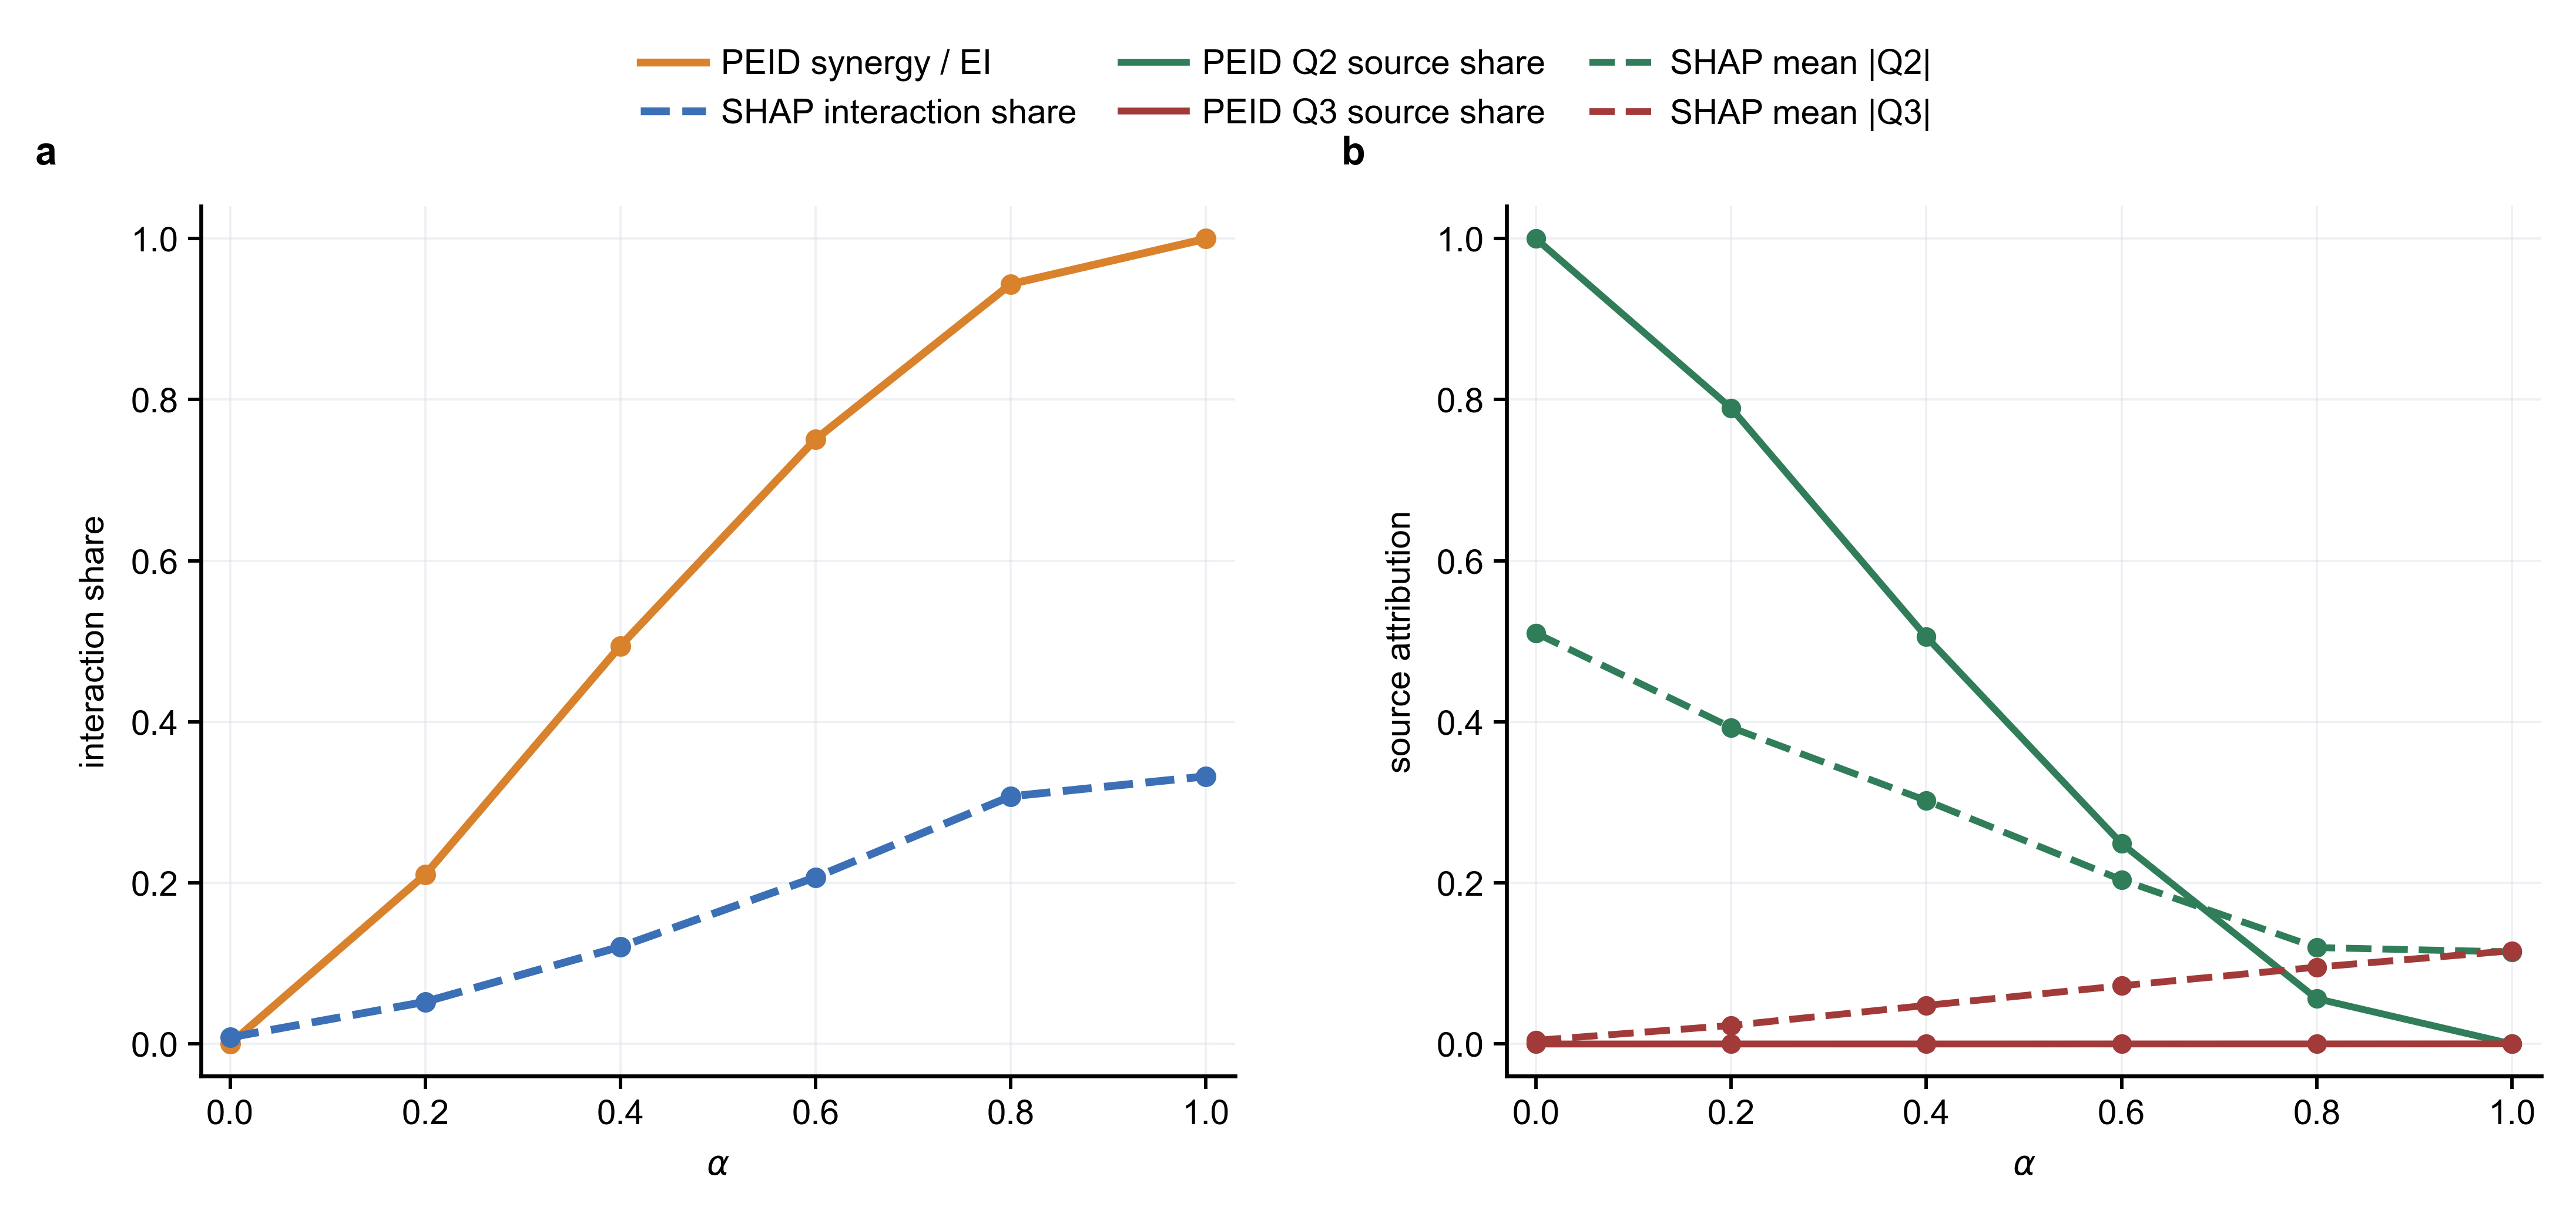

,alpha,L,q1_noise_std,tm_ei_mean,tm_syn_mean,tm_syn_ratio,tm_single_q2_ratio,tm_single_q3_ratio,shap_mean_abs_q2_mean,shap_mean_abs_q2_std,shap_mean_abs_q3_mean,shap_mean_abs_q3_std,shap_pair_interaction_mean,shap_pair_interaction_std,shap_interaction_share_mean,shap_interaction_share_std,model_r2_mean,model_r2_std
0,0.0,2.0,0.05,2.447424,0.000437,0.000179,0.999800,0.000021,0.510185,0.007960,0.004531,0.000274,0.004273,0.000066,0.008233,0.000004,0.991931,0.000006
1,0.2,2.0,0.05,2.229365,0.468921,0.210339,0.789599,0.000062,0.392996,0.009095,0.023034,0.000443,0.022997,0.000352,0.052385,0.000378,0.986204,0.002529
2,0.4,2.0,0.05,1.999371,0.988454,0.494383,0.505562,0.000056,0.302227,0.001934,0.047924,0.001881,0.048128,0.001194,0.120830,0.001477,0.978888,0.000772
3,0.6,2.0,0.05,1.779275,1.336126,0.750938,0.248969,0.000093,0.203865,0.013627,0.072360,0.003886,0.072079,0.003270,0.207032,0.002966,0.968599,0.001784
4,0.8,2.0,0.05,1.715663,1.618834,0.943562,0.056335,0.000103,0.119749,0.001940,0.095439,0.004806,0.095595,0.004914,0.307513,0.004276,0.959698,0.002601
5,1.0,2.0,0.05,1.813023,1.812667,0.999803,0.000032,0.000165,0.114368,0.001623,0.115840,0.002497,0.114587,0.001962,0.332335,0.000173,0.961555,0.005367


In [4]:
from IPython.display import Image, display
from matplotlib.lines import Line2D

shap_runs, shap_summary = load_or_run_csvs(
    runs_path=OUTPUT_DIR / "tm_alpha_shap_runs.csv",
    summary_path=OUTPUT_DIR / "tm_alpha_shap_summary.csv",
    runner=lambda: compute_shap_alpha_comparison(
        alpha_values=DEFAULT_ALPHA_VALUES,
        config=CONFIG,
        shap_config=SHAP_CONFIG,
    ),
    summarizer=summarize_shap_runs,
    force=FORCE_RECOMPUTE,
)

shap_peid_comparison = build_shap_peid_comparison(alpha_summary, shap_summary)
shap_peid_comparison.to_csv(OUTPUT_DIR / "tm_alpha_shap_peid_comparison.csv", index=False)

plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans", "sans-serif"],
        "font.size": 7,
        "axes.spines.right": False,
        "axes.spines.top": False,
        "axes.linewidth": 0.8,
        "pdf.fonttype": 42,
        "svg.fonttype": "none",
    }
)

fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.05), constrained_layout=True)
fig.set_constrained_layout_pads(w_pad=0.04, h_pad=0.04, wspace=0.08, hspace=0.04)
alpha = shap_peid_comparison["alpha"].to_numpy(dtype=float)

styles = {
    "peid_signal": {"color": "#d9822b", "marker": "o", "linewidth": 1.6, "markersize": 3.2, "linestyle": "-"},
    "shap_signal": {"color": "#3b6fb6", "marker": "o", "linewidth": 1.6, "markersize": 3.2, "linestyle": "--"},
    "q2_peid": {"color": "#2f7d59", "marker": "o", "linewidth": 1.4, "markersize": 3.0, "linestyle": "-"},
    "q3_peid": {"color": "#a33a3a", "marker": "o", "linewidth": 1.4, "markersize": 3.0, "linestyle": "-"},
    "q2_shap": {"color": "#2f7d59", "marker": "o", "linewidth": 1.4, "markersize": 3.0, "linestyle": "--"},
    "q3_shap": {"color": "#a33a3a", "marker": "o", "linewidth": 1.4, "markersize": 3.0, "linestyle": "--"},
}

handles = [
    axes[0].plot(alpha, shap_peid_comparison["tm_syn_ratio"], label="PEID synergy / EI", **styles["peid_signal"])[0],
    axes[0].plot(alpha, shap_peid_comparison["shap_interaction_share_mean"], label="SHAP interaction share", **styles["shap_signal"])[0],
]
axes[0].set_ylabel("interaction share")

handles.extend(
    [
        axes[1].plot(alpha, shap_peid_comparison["tm_single_q2_ratio"], label="PEID Q2 source share", **styles["q2_peid"])[0],
        axes[1].plot(alpha, shap_peid_comparison["tm_single_q3_ratio"], label="PEID Q3 source share", **styles["q3_peid"])[0],
        axes[1].plot(alpha, shap_peid_comparison["shap_mean_abs_q2_mean"], label="SHAP mean |Q2|", **styles["q2_shap"])[0],
        axes[1].plot(alpha, shap_peid_comparison["shap_mean_abs_q3_mean"], label="SHAP mean |Q3|", **styles["q3_shap"])[0],
    ]
)
axes[1].set_ylabel("source attribution")

for panel_label, ax in zip(("a", "b"), axes):
    ax.text(-0.16, 1.04, panel_label, transform=ax.transAxes, fontsize=8, fontweight="bold", va="bottom")
    ax.set_xlabel(r"$\alpha$")
    ax.set_xlim(-0.03, 1.03)
    ax.set_ylim(-0.04, 1.04)
    ax.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.grid(color="#d9dee7", alpha=0.45, linewidth=0.45)
    ax.tick_params(length=2.6, width=0.7, pad=2)

legend_handles = [
    Line2D([0], [0], color=handle.get_color(), linestyle=handle.get_linestyle(), linewidth=handle.get_linewidth())
    for handle in handles
]
fig.legend(
    legend_handles,
    [handle.get_label() for handle in handles],
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=3,
    frameon=False,
    handlelength=1.9,
    columnspacing=1.3,
    handletextpad=0.45,
    borderaxespad=0.0,
)

fig.savefig(OUTPUT_DIR / "tm_alpha_shap_peid_comparison.png", dpi=600, bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "tm_alpha_shap_peid_comparison.pdf", bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "tm_alpha_shap_peid_comparison.svg", bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "tm_alpha_shap_peid_comparison.tiff", dpi=600, bbox_inches="tight")

plt.close(fig)
display(Image(filename=str(OUTPUT_DIR / "tm_alpha_shap_peid_comparison.png")))
shap_peid_comparison

**读法。** 左图中，PEID 的协同比例

$$
\frac{\mathrm{Syn}^{\mathrm{tm}}(Q_2,Q_3 \to Q_1)}{\mathrm{EI}^{\mathrm{tm}}(Q_2,Q_3 \to Q_1)}
$$

随 `alpha` 从接近 0 上升到接近 1，说明 TM/PEID 正在把信息从单源项读到联合非线性项中。SHAP interaction share 也随 `alpha` 上升，方向一致，但数值更低，因为它来自随机森林预测模型的 Shapley 交互解释，而不是干预分布下的有效信息分解。

`Q_3` 的 SHAP 归因随 `alpha` 变化并不奇怪。当前目标动力学是

$$
Q_1^{n+1}=\alpha\sin(Q_2^nQ_3^n)+(1-\alpha)Q_2^n+\varepsilon.
$$

当 `alpha = 0` 时，模型对 `Q_3` 的真实依赖为零；当 `alpha` 增大时，`Q_3` 通过乘积项进入目标。SHAP 对单个变量的归因由边际贡献定义：

$$
\phi_i=\sum_{S\subseteq N\setminus\{i\}}\frac{|S|!(|N|-|S|-1)!}{|N|!}\left[v(S\cup\{i\})-v(S)\right].
$$

其中 $v(S)$ 是只知道特征集合 $S$ 时模型输出的期望。因此即使 `Q_3` 只通过 $\sin(Q_2Q_3)$ 这种联合机制起作用，只要加入 `Q_3` 会改变模型预测，SHAP 就会给 `Q_3` 分配非零归因。

这不是简单的“SHAP 算错了”，而是 SHAP 方法的语义限制：它会把不可约的联合机制分摊到单变量归因和交互归因中。对这类协同系统，单看 mean $|\phi_{Q_3}|$ 容易把“联合项中的必要变量”误读成“单独有效的变量”。因此这里更稳妥的读法是：用 SHAP interaction share 判断预测模型是否学到交互趋势，用 PEID 的 $\mathrm{Syn}/\mathrm{EI}$ 判断干预机制中的协同信息强度。

## Beta sweep: 幂指数分配下的 PEID 与 SHAP

这里加入新的动力学：

$$
Q_1^{n+1}=\sin\left((Q_2^n)^\beta (Q_3^n)^{1-\beta}\right)+\varepsilon.
$$

其他参数沿用上面的低噪声设置。由于当前干预分布仍是对称区间 $[-L/2,L/2]$，分数次幂在负数上需要实值约定；实现中使用带符号实幂 $\operatorname{sgn}(x)|x|^p$，并把 $p=0$ 视为常数 1。这样 `beta = 0` 接近纯 `Q_3` 通道，`beta = 1` 接近纯 `Q_2` 通道，中间 beta 则需要两个源共同决定目标。


In [5]:
beta_runs, beta_summary = load_or_run_csvs(
    runs_path=OUTPUT_DIR / "tm_beta_runs.csv",
    summary_path=OUTPUT_DIR / "tm_beta_summary.csv",
    runner=lambda: run_beta_sweep_tm(
        beta_values=DEFAULT_BETA_VALUES,
        n_samples=CONFIG.n_samples,
        repeats=CONFIG.repeats,
        L=CONFIG.input_box_width,
        q1_noise_std=CONFIG.q1_noise_std,
        seed=CONFIG.seed,
    ),
    summarizer=lambda runs: summarize_tm_runs(runs, group_columns=["beta", "L", "q1_noise_std"]),
    force=FORCE_RECOMPUTE,
)

plot_beta_sweep_tm(beta_summary, output_dir=OUTPUT_DIR)
beta_summary


,beta,L,q1_noise_std,tm_ei_mean,tm_ei_std,tm_syn_mean,tm_syn_std,tm_single_q2_mean,tm_single_q2_std,tm_single_q3_mean,tm_single_q3_std,tm_syn_ratio,tm_single_q2_ratio,tm_single_q3_ratio
0,0.0,2.0,0.05,2.250796,0.014269,-0.098026,0.004187,0.000156,0.000180,2.348667,0.014397,-0.043552,0.000069,1.043483
1,0.2,2.0,0.05,0.902230,0.013855,0.902022,0.013911,0.000000,0.000000,0.000208,0.000153,0.999769,0.000000,0.000231
2,0.4,2.0,0.05,1.074051,0.008488,1.073274,0.008773,0.000587,0.000737,0.000190,0.000379,0.999277,0.000547,0.000177
3,0.6,2.0,0.05,1.076041,0.014471,1.075844,0.014448,0.000120,0.000150,0.000077,0.000154,0.999817,0.000112,0.000071
4,0.8,2.0,0.05,0.905739,0.012354,0.905115,0.012510,0.000610,0.000597,0.000014,0.000028,0.999311,0.000673,0.000016
5,1.0,2.0,0.05,2.241801,0.006431,-0.104485,0.006794,2.346186,0.011574,0.000100,0.000119,-0.046608,1.046563,0.000045


**读法。** `beta = 0` 与 `beta = 1` 分别退化为单源非线性通道，预期 `Syn / EI` 较低，且主导单源应从 `Q_3` 平滑切换到 `Q_2`。中间 `beta` 同时需要两个源，若 PEID 能读出该联合依赖，`Syn / EI` 应在中间区间抬高。


## Beta sweep 的 SHAP 对照

这一步使用与 alpha 对照相同的随机森林和 TreeSHAP 配置，只把横轴改为 `beta`。左图比较 PEID 协同比例与 SHAP interaction share，右图比较 PEID 单源占比与 SHAP mean absolute attribution。


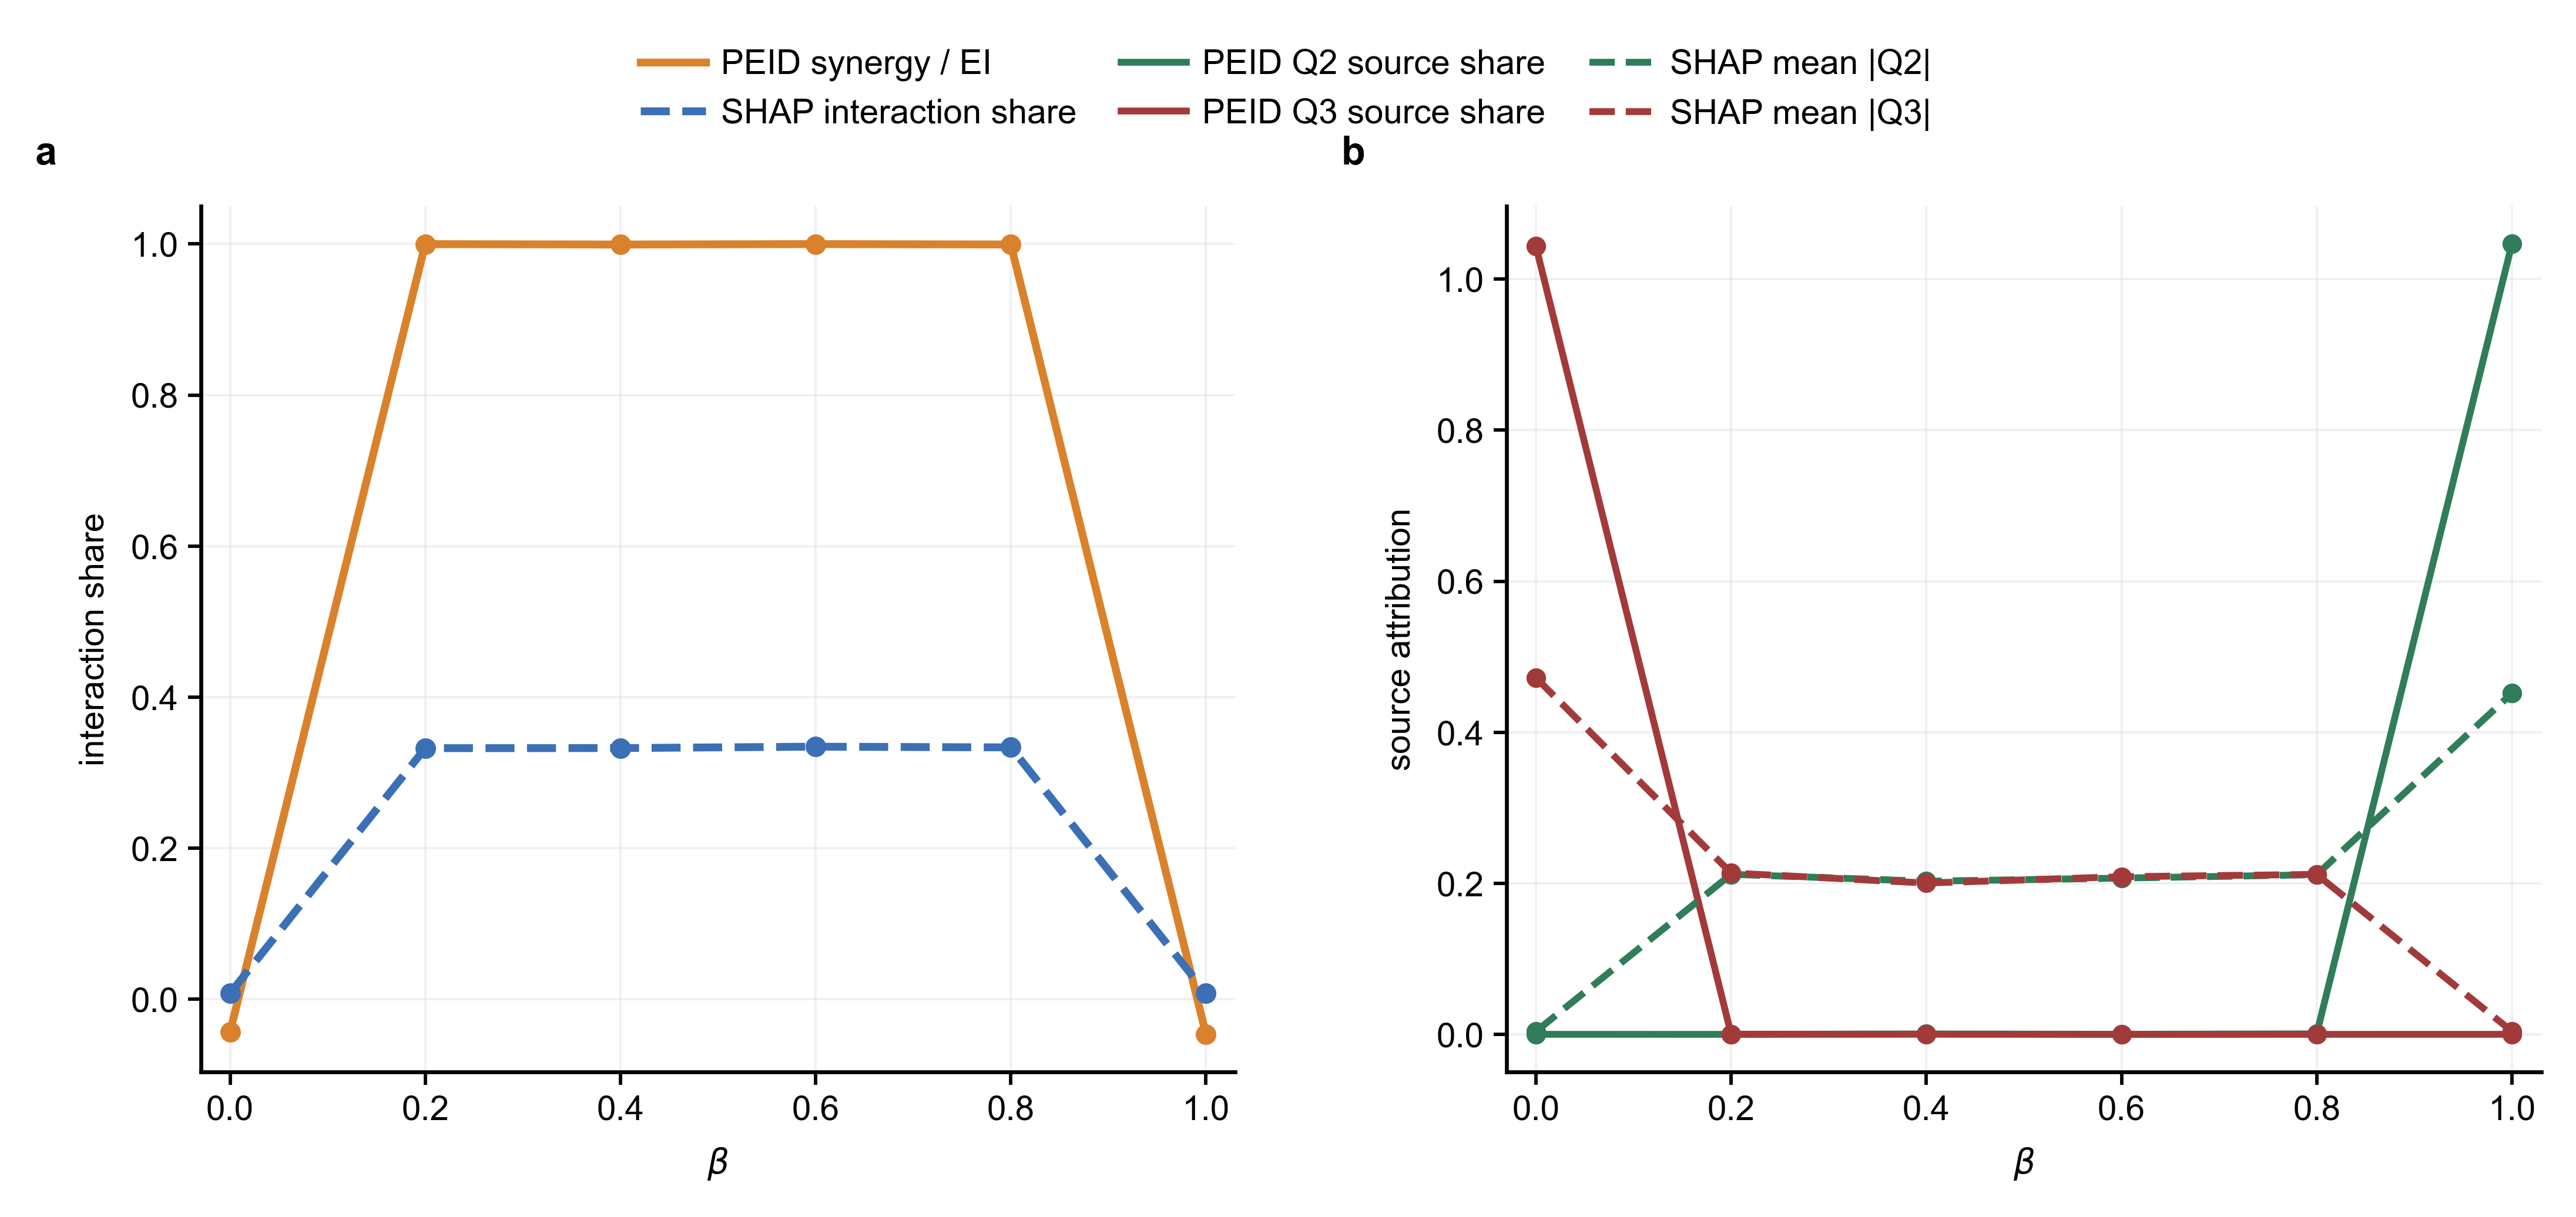

,beta,L,q1_noise_std,tm_ei_mean,tm_syn_mean,tm_syn_ratio,tm_single_q2_ratio,tm_single_q3_ratio,shap_mean_abs_q2_mean,shap_mean_abs_q2_std,shap_mean_abs_q3_mean,shap_mean_abs_q3_std,shap_pair_interaction_mean,shap_pair_interaction_std,shap_interaction_share_mean,shap_interaction_share_std,model_r2_mean,model_r2_std
0,0.0,2.0,0.05,2.250796,-0.098026,-0.043552,0.000069,1.043483,0.003915,0.000376,0.472148,0.005679,0.003690,0.000479,0.007697,0.001076,0.990505,0.000224
1,0.2,2.0,0.05,0.902230,0.902022,0.999769,0.000000,0.000231,0.211925,0.000468,0.213642,0.002890,0.211850,0.001277,0.332359,0.000414,0.976650,0.006656
2,0.4,2.0,0.05,1.074051,1.073274,0.999277,0.000547,0.000177,0.202757,0.005965,0.200373,0.006969,0.200754,0.003735,0.332479,0.002992,0.982213,0.000530
3,0.6,2.0,0.05,1.076041,1.075844,0.999817,0.000112,0.000071,0.206899,0.002070,0.208708,0.002228,0.208756,0.002249,0.334349,0.000096,0.986000,0.000380
4,0.8,2.0,0.05,0.905739,0.905115,0.999311,0.000673,0.000016,0.211423,0.000554,0.211796,0.001969,0.211646,0.001487,0.333370,0.000818,0.986289,0.000140
5,1.0,2.0,0.05,2.241801,-0.104485,-0.046608,1.046563,0.000045,0.451657,0.008395,0.004088,0.000131,0.003713,0.000470,0.008091,0.001161,0.989413,0.000148


In [6]:
beta_shap_runs, beta_shap_summary = load_or_run_csvs(
    runs_path=OUTPUT_DIR / "tm_beta_shap_runs.csv",
    summary_path=OUTPUT_DIR / "tm_beta_shap_summary.csv",
    runner=lambda: compute_shap_beta_comparison(
        beta_values=DEFAULT_BETA_VALUES,
        config=CONFIG,
        shap_config=SHAP_CONFIG,
    ),
    summarizer=lambda runs: summarize_shap_runs(runs, group_columns=["beta", "L", "q1_noise_std"]),
    force=FORCE_RECOMPUTE,
)

beta_shap_peid_comparison = build_shap_peid_comparison(beta_summary, beta_shap_summary, sweep_column="beta")
beta_shap_peid_comparison.to_csv(OUTPUT_DIR / "tm_beta_shap_peid_comparison.csv", index=False)

fig = plot_beta_shap_peid_comparison(beta_shap_peid_comparison, output_dir=OUTPUT_DIR)
plt.close(fig)
display(Image(filename=str(OUTPUT_DIR / "tm_beta_shap_peid_comparison.png")))
beta_shap_peid_comparison


**读法。** 若 SHAP 学到的是预测曲面上的联合依赖，它的 interaction share 应在中间 `beta` 区间升高；但 mean $|\phi_{Q_2}|$ 与 mean $|\phi_{Q_3}|$ 会随指数权重重新分摊贡献，不等同于 PEID 的单源机制强度。这里仍按趋势比较，不把 SHAP 数值解释为机制 EI。


## 高噪声对照

这里把目标噪声从 `0.05` 提高到 `0.6`。该实验检查结构类型是否仍能被读出，而不是只看绝对 EI 是否下降。

In [7]:
high_noise_runs, high_noise_summary = load_or_run_csvs(
    runs_path=OUTPUT_DIR / "tm_alpha_high_noise_runs.csv",
    summary_path=OUTPUT_DIR / "tm_alpha_high_noise_summary.csv",
    runner=lambda: run_alpha_sweep_tm(
        alpha_values=DEFAULT_ALPHA_VALUES,
        n_samples=CONFIG.n_samples,
        repeats=CONFIG.repeats,
        L=CONFIG.input_box_width,
        q1_noise_std=CONFIG.high_noise_std,
        seed=CONFIG.seed + 50000,
    ),
    summarizer=lambda runs: summarize_tm_runs(runs, group_columns=["alpha", "L", "q1_noise_std"]),
    force=FORCE_RECOMPUTE,
)

plot_alpha_high_noise_decomposition(high_noise_summary, output_dir=OUTPUT_DIR)
high_noise_summary

,alpha,L,q1_noise_std,tm_ei_mean,tm_ei_std,tm_syn_mean,tm_syn_std,tm_single_q2_mean,tm_single_q2_std,tm_single_q3_mean,tm_single_q3_std,tm_syn_ratio,tm_single_q2_ratio,tm_single_q3_ratio
0,0.0,2.0,0.6,0.327546,0.008883,-0.000023,0.000221,0.327474,0.008752,0.000094,0.000081,-0.000069,0.999781,0.000288
1,0.2,2.0,0.6,0.240604,0.009441,0.005217,0.001249,0.235349,0.008700,0.000038,0.000045,0.021681,0.978161,0.000158
2,0.4,2.0,0.6,0.157219,0.007461,0.019073,0.004032,0.137990,0.004293,0.000156,0.000222,0.121314,0.877693,0.000993
3,0.6,2.0,0.6,0.113517,0.004580,0.046411,0.004013,0.067091,0.001538,0.000015,0.000030,0.408847,0.591021,0.000132
4,0.8,2.0,0.6,0.095091,0.010954,0.079975,0.010377,0.015116,0.001676,0.000000,0.000000,0.841036,0.158964,0.000000
5,1.0,2.0,0.6,0.118109,0.011333,0.117770,0.011228,0.000306,0.000304,0.000033,0.000066,0.997132,0.002588,0.000280


**读法。** 高噪声会压低所有 EI 绝对值；关键是 `alpha = 1` 的协同比例是否仍明显高于 `alpha = 0`。如果比例也坍缩，说明观测噪声不仅降低可解释信息总量，也会改变 TM/PEID 对结构类型的分解。

## L 敏感性

`L` 改变干预盒范围，也改变 `sin(Q_2 Q_3)` 被采样到的非线性形状。这里用 `alpha = 0, 0.5, 1` 三个代表性结构检查 PEID 对干预范围的敏感性。

In [8]:
l_runs, l_summary = load_or_run_csvs(
    runs_path=OUTPUT_DIR / "tm_l_sweep_runs.csv",
    summary_path=OUTPUT_DIR / "tm_l_sweep_summary.csv",
    runner=lambda: run_l_sweep_tm(
        l_values=DEFAULT_L_VALUES,
        alpha_values=DEFAULT_L_SWEEP_ALPHA_VALUES,
        config=CONFIG,
    ),
    summarizer=lambda runs: summarize_tm_runs(runs, group_columns=["L", "alpha", "q1_noise_std"]),
    force=FORCE_RECOMPUTE,
)

plot_l_sweep_tm(l_summary, output_dir=OUTPUT_DIR)
l_summary

,L,alpha,q1_noise_std,tm_ei_mean,tm_ei_std,tm_syn_mean,tm_syn_std,tm_single_q2_mean,tm_single_q2_std,tm_single_q3_mean,tm_single_q3_std,tm_syn_ratio,tm_single_q2_ratio,tm_single_q3_ratio
0,1.0,0.0,0.05,1.778797,0.002989,-0.000240,0.000425,1.778747,0.003124,0.000289,0.000295,-0.000135,0.999972,0.000163
1,2.0,0.0,0.05,2.448880,0.014082,-0.000241,0.000310,2.448896,0.014132,0.000225,0.000350,-0.000098,1.000007,0.000092
2,4.0,0.0,0.05,3.141014,0.023399,0.000360,0.000699,3.140546,0.023720,0.000108,0.000216,0.000115,0.999851,0.000034
3,6.0,0.0,0.05,3.548320,0.010772,0.000008,0.000261,3.548248,0.010928,0.000064,0.000128,0.000002,0.999980,0.000018
4,8.0,0.0,0.05,3.837559,0.019739,-0.000341,0.000477,3.837773,0.019455,0.000127,0.000216,-0.000089,1.000056,0.000033
5,10.0,0.0,0.05,4.055087,0.005831,0.000029,0.000433,4.055047,0.006128,0.000010,0.000021,0.000007,0.999990,0.000003
6,12.0,0.0,0.05,4.258795,0.009411,-0.000039,0.000322,4.258834,0.009712,0.000000,0.000000,-0.000009,1.000009,0.000000
7,1.0,0.5,0.05,1.141481,0.015768,0.261642,0.012804,0.879557,0.004791,0.000282,0.000564,0.229213,0.770540,0.000247
8,2.0,0.5,0.05,1.890751,0.021351,1.183506,0.023463,0.706760,0.003455,0.000485,0.000760,0.625945,0.373799,0.000256
9,4.0,0.5,0.05,1.104282,0.009961,0.382161,0.021249,0.722121,0.012215,0.000000,0.000000,0.346072,0.653928,0.000000


**读法。** `alpha = 0` 若在所有 `L` 下维持低 `Syn`，说明扩大干预范围本身不会系统性制造协同。`alpha = 1` 若随 `L` 出现明显变化，则说明 PEID 估计不仅取决于结构项是否存在，也取决于干预分布覆盖到的局部/周期性形状。

## 固定 alpha 的噪声扫描

最后固定 `L`，逐步增加目标噪声，分别观察 `alpha = 0, 0.5, 1` 下整体 EI、单源 EI 和协同 EI 如何退化。

In [9]:
noise_runs, noise_summary = load_or_run_csvs(
    runs_path=OUTPUT_DIR / "tm_fixed_alpha_noise_sweep_runs.csv",
    summary_path=OUTPUT_DIR / "tm_fixed_alpha_noise_sweep_summary.csv",
    runner=lambda: run_fixed_alpha_noise_sweep_tm(
        alpha_values=DEFAULT_NOISE_SWEEP_ALPHA_VALUES,
        noise_std_values=DEFAULT_NOISE_STD_VALUES,
        config=CONFIG,
    ),
    summarizer=lambda runs: summarize_tm_runs(runs, group_columns=["alpha", "q1_noise_std", "L"]),
    force=FORCE_RECOMPUTE,
)

plot_fixed_alpha_noise_sweep_tm(noise_summary, output_dir=OUTPUT_DIR)
noise_summary

,alpha,q1_noise_std,L,tm_ei_mean,tm_ei_std,tm_syn_mean,tm_syn_std,tm_single_q2_mean,tm_single_q2_std,tm_single_q3_mean,tm_single_q3_std,tm_syn_ratio,tm_single_q2_ratio,tm_single_q3_ratio
0,0.0,0.00,2.0,6.516295,0.007206,-0.000250,1.740405e-11,6.516545,0.007206,0.000000e+00,0.000000e+00,-0.000038,1.000038,0.000000e+00
1,0.0,0.02,2.0,3.361797,0.009537,-0.000007,2.714158e-04,3.361802,0.009378,1.790727e-06,3.581453e-06,-0.000002,1.000001,5.326694e-07
2,0.0,0.05,2.0,2.460290,0.006187,-0.000044,5.041170e-04,2.460186,0.006344,1.477200e-04,2.954400e-04,-0.000018,0.999958,6.004171e-05
3,0.0,0.10,2.0,1.765681,0.011670,-0.000033,2.928768e-04,1.765714,0.011386,0.000000e+00,0.000000e+00,-0.000019,1.000019,0.000000e+00
4,0.0,0.20,2.0,1.125334,0.009493,-0.000228,3.197708e-04,1.125322,0.009432,2.399796e-04,2.762611e-04,-0.000203,0.999989,2.132518e-04
5,0.0,0.40,2.0,0.564089,0.018629,-0.000018,2.404814e-04,0.564100,0.018433,6.864539e-06,1.372908e-05,-0.000032,1.000020,1.216925e-05
6,0.0,0.60,2.0,0.323055,0.011544,-0.000092,4.241131e-05,0.323063,0.011685,8.457719e-05,1.691544e-04,-0.000285,1.000023,2.618042e-04
7,0.0,0.80,2.0,0.209921,0.005842,-0.000170,3.017624e-04,0.210046,0.005937,4.482015e-05,8.964029e-05,-0.000810,1.000597,2.135099e-04
8,0.0,1.00,2.0,0.145887,0.003287,0.000279,2.837002e-04,0.145479,0.003084,1.280235e-04,1.509696e-04,0.001913,0.997210,8.775554e-04
9,0.5,0.00,2.0,3.959919,0.016934,3.228067,1.080173e-02,0.731757,0.010137,9.504027e-05,1.900805e-04,0.815185,0.184791,2.400056e-05


**读法。** 噪声增强时绝对 `EI` 下降是预期结果。更有诊断价值的是比例：`alpha = 0` 应主要保留 `Q_2` 单源占比，`alpha = 1` 应主要保留协同占比；`alpha = 0.5` 则应位于二者之间。

## 输出清单

所有长实验结果都写入 CSV，图同时输出 PNG/PDF，便于后续文档直接引用。

In [10]:
manifest = {
    "notebook": "exp/TM/tm_nonlinear.ipynb",
    "alpha_values": list(DEFAULT_ALPHA_VALUES),
    "beta_values": list(DEFAULT_BETA_VALUES),
    "l_values": list(DEFAULT_L_VALUES),
    "noise_std_values": list(DEFAULT_NOISE_STD_VALUES),
    "csv": [
        "tm_alpha_runs.csv",
        "tm_alpha_summary.csv",
        "tm_alpha_shap_runs.csv",
        "tm_alpha_shap_summary.csv",
        "tm_alpha_shap_peid_comparison.csv",
        "tm_beta_runs.csv",
        "tm_beta_summary.csv",
        "tm_beta_shap_runs.csv",
        "tm_beta_shap_summary.csv",
        "tm_beta_shap_peid_comparison.csv",
        "tm_alpha_high_noise_runs.csv",
        "tm_alpha_high_noise_summary.csv",
        "tm_l_sweep_runs.csv",
        "tm_l_sweep_summary.csv",
        "tm_fixed_alpha_noise_sweep_runs.csv",
        "tm_fixed_alpha_noise_sweep_summary.csv",
    ],
    "figures": [
        "tm_alpha_ei_decomposition.png",
        "tm_alpha_share_ratio.png",
        "tm_alpha_shap_peid_comparison.png",
        "tm_beta_ei_decomposition.png",
        "tm_beta_share_ratio.png",
        "tm_beta_shap_peid_comparison.png",
        "tm_alpha_high_noise_ei_decomposition.png",
        "tm_l_sensitivity_heatmap.png",
        "tm_l_sensitivity_lines.png",
        "tm_fixed_alpha_noise_sweep_decomposition.png",
        "tm_fixed_alpha_noise_sweep_share_ratio.png",
    ],
}
write_manifest(OUTPUT_DIR, name="tm_nonlinear_manifest.json", payload=manifest)
manifest


{'notebook': 'exp/TM/tm_nonlinear.ipynb',
 'alpha_values': [0.0, 0.2, 0.4, 0.6, 0.8, 1.0],
 'beta_values': [0.0, 0.2, 0.4, 0.6, 0.8, 1.0],
 'l_values': [1.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0],
 'noise_std_values': [0.0, 0.02, 0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0],
 'csv': ['tm_alpha_runs.csv',
  'tm_alpha_summary.csv',
  'tm_alpha_shap_runs.csv',
  'tm_alpha_shap_summary.csv',
  'tm_alpha_shap_peid_comparison.csv',
  'tm_beta_runs.csv',
  'tm_beta_summary.csv',
  'tm_beta_shap_runs.csv',
  'tm_beta_shap_summary.csv',
  'tm_beta_shap_peid_comparison.csv',
  'tm_alpha_high_noise_runs.csv',
  'tm_alpha_high_noise_summary.csv',
  'tm_l_sweep_runs.csv',
  'tm_l_sweep_summary.csv',
  'tm_fixed_alpha_noise_sweep_runs.csv',
  'tm_fixed_alpha_noise_sweep_summary.csv'],
 'figures': ['tm_alpha_ei_decomposition.png',
  'tm_alpha_share_ratio.png',
  'tm_alpha_shap_peid_comparison.png',
  'tm_beta_ei_decomposition.png',
  'tm_beta_share_ratio.png',
  'tm_beta_shap_peid_comparison.png',
  'tm_alpha_high_